# 030 模块数据加载与训练循环

目标：检查训练/验证/测试职责与完整epoch恢复。实际CPU合成实验：17参数、84次更新；完整恢复与参照最终状态相同，不能推出跨平台或真实任务表现。先读lecture.pdf和lab.pdf。

## 设置
从本讲目录打开，重启内核后顺序执行。先校验固定输入与原始输出；发现变动就停止，不把旧图冒充新实验。

In [1]:
from pathlib import Path
import hashlib
ROOT = Path.cwd()
EXPECTED = {'data/config.json': '415dfe8ed8750b983b454ab38629ee36fb282f3e9449c955065445abc9eca238', 'data/samples.csv': 'e26f750b0e4c25f0dcdd53100a395a86b21f96d056b91365010da4cf68eb6c4c', 'data/split.json': '43298159b4808eb3b80fe841d347f26543cbb95212f657fa7a5ea86a1fd2d98f', 'outputs/checkpoint-epoch-04.pt': 'e548b062fdfe9e7bbb943e3069e1a31932d8afe9d60342ab6bf8e74e8c88e414', 'outputs/final-state.json': '493efb4a4cf67dc579a274123ef4154cd51f7dc7f1ea1f7f724d2156d1abb684', 'outputs/first-step-trace.json': '5d7edef4392ea939d53d66d76de245390a56934fe9c3c4153fa7ea92e9df4632', 'outputs/history.csv': '9a9c11c9068c0d3caa697aa154d7a7d1a62c285064b5b4a789089c29de72b575', 'outputs/orders.json': '2f843bdeabc35b1d6075d24e6a0eae82cf6367014b98fd98a3728f81a31e6ea4', 'outputs/semantics.json': '649b502af008fbff9891fa448b2a4fef2971f17122a086e9fc9e3c598d5b6abd', 'outputs/summary.json': 'a2c6a776f53c4d10018efbee8230e8e812d49d7942ce6aa8b6a4dc3d701e26dc', 'outputs/test-predictions.json': 'e91924ef3f77c74190e04d9bfec09f88a19424ab39ea578baeec320290e5cd1b'}
for name, digest in EXPECTED.items():
    if hashlib.sha256((ROOT/name).read_bytes()).hexdigest() != digest:
        raise ValueError('固定报告文件已变动: '+name)
print('3份输入与8份原始输出已核对')

3份输入与8份原始输出已核对


In [2]:
import json, copy, tempfile
import torch
import experiment as e
x,y,split,cfg=e.load_inputs()
print('torch',torch.__version__,'dtype',x.dtype,'device',x.device)
print({name:len(ids) for name,ids in split.items()})

torch 2.7.1+cpu dtype torch.float64 device cpu
{'train': 45, 'validation': 15, 'test': 12}


## 参数注册与形状
模型2→4→1；训练标准化统计量是buffer，不交给优化器。

In [3]:
run=e.make_run(x,y,split,cfg)
print([(name,tuple(p.shape)) for name,p in run['model'].named_parameters()])
print([(name,tuple(b.shape)) for name,b in run['model'].named_buffers()])
print('参数数',sum(p.numel() for p in run['model'].parameters()))

[('hidden.weight', (4, 2)), ('hidden.bias', (4,)), ('output.weight', (1, 4)), ('output.bias', (1,))]
[('mean', (2,)), ('scale', (2,))]
参数数 17


## 查看批次不会没有副作用
遍历训练loader会推进打乱生成器。此处查看后重新构造run，再开展正式训练。

In [4]:
batches=list(run['loaders']['train'])
print('批次大小',[len(yb) for xb,yb,ids in batches])
print('ID完整',sorted(i for xb,yb,ids in batches for i in ids.tolist())==split['train'])
run=e.make_run(x,y,split,cfg)

批次大小 [7, 7, 7, 7, 7, 7, 3]
ID完整 True


## 手算与错误归约
2行均值1、3行均值4，正确结果按样本数加权。eval与no_grad各自控制不同机制。

In [5]:
probes=e.semantic_probes()
print(json.dumps(probes,ensure_ascii=False,indent=2))

{
  "unregistered_parameter_names": [],
  "unregistered_w_has_gradient": true,
  "registered_parameter_names": [
    "w",
    "layers.0.weight",
    "layers.0.bias"
  ],
  "shallow_state_changed": true,
  "clone_state_unchanged": true,
  "momentum_hand": [
    {
      "parameter": 0.8,
      "buffer": 2.0
    },
    {
      "parameter": 0.4,
      "buffer": 4.0
    }
  ],
  "eval_does_not_prevent_update": true,
  "no_grad_train_dropout_changes_output": true,
  "uneven_hand": {
    "batch_sizes": [
      2,
      3
    ],
    "batch_means": [
      1.0,
      4.0
    ],
    "correct": 2.8,
    "wrong_equal": 2.5
  }
}


## 从头重新生成完整报告
计算在临时目录中完成，不覆盖提供的outputs；所有8份输出逐字节比较，包含自己的检查点。

In [6]:
temporary=tempfile.TemporaryDirectory()
result_dir=Path(temporary.name)
summary=e.write_report(result_dir)
matched={name:(result_dir/name).read_bytes()==(ROOT/'outputs'/name).read_bytes() for name in [p.name for p in (ROOT/'outputs').iterdir()]}
if not all(matched.values()):
    raise RuntimeError('新运行与固定报告不一致')
print(matched)
print('最佳轮次',summary['best_epoch'],'验证',summary['best_validation_mse'],'测试',summary['test_mse'])

{'checkpoint-epoch-04.pt': True, 'first-step-trace.json': True, 'summary.json': True, 'orders.json': True, 'test-predictions.json': True, 'final-state.json': True, 'history.csv': True, 'semantics.json': True}
最佳轮次 10 验证 0.045871487874647246 测试 0.13905110201369023


## 同一首批逐量核对
全部数值来自主实验同一首批；先读正文5.4，沿一个样本追踪，再把七条路径合到每个共享参数。

In [7]:
trace=json.loads((result_dir/'first-step-trace.json').read_text())
print('ID',trace['ids'],'loss',trace['loss'])
for name, value in trace['values'].items():
    print(name,trace['shapes'][name],value)

ID [56, 10, 26, 43, 14, 11, 2] loss 1.2625612818920995
x [7, 2] [[0.8, 0.75], [0.8, 1.0], [1.0, 0.5], [-0.8, 1.75], [2.0, -1.5], [-1.2, -2.0], [-1.6, 1.25]]
target [7, 1] [[0.3299999999999999], [0.21999999999999995], [0.5499999999999999], [-1.49], [1.5], [0.39000000000000007], [-2.02]]
normalized [7, 2] [[0.5726893213029343, 0.6810561772075411], [0.5726893213029343, 0.8738079254738262], [0.716661497049482, 0.4883044289412558], [-0.5790880846694476, 1.4520631702726818], [1.4365223757822208, -1.0537095571890258], [-0.867032436162543, -1.4392130537215961], [-1.1549767876556385, 1.0665596737401115]]
affine [7, 4] [[0.11257468217713196, 1.016275533058828, 0.1301742103670318, -0.5171623212979481], [0.15448785774416735, 1.0186325389694417, 0.1659111428358382, -0.43019876184324335], [0.15190606184343886, 1.090965107010815, 0.14077598363689858, -0.6812416689799682], [-0.36972905742146456, 0.40933091780047787, -0.09758770566712806, 0.44761822233939275], [0.22282343347386707, 1.4573419590389083, 

In [8]:
print('全部参数梯度',trace['gradients'])
print('更新前',trace['before'])
print('更新后',trace['after'])
print('同一批次下一次eval前向',trace['next_forward_same_batch_eval'])
print('固定原掩码重放',trace['next_forward_fixed_original_mask'])

全部参数梯度 {'hidden.weight': [[0.08392757849613924, -0.1458236316741813], [-0.1286580224270945, 0.20323552372419226], [0.4740825166726622, -0.47972920816374987], [0.3656947046302082, -0.5206665046430892]], 'hidden.bias': [-0.13201142613875552, 0.17088028269401082, -0.19356893727319108, -0.49893842691546003], 'output.weight': [[-0.8366367688645455, 0.040806113630689866, -0.2937615182854782, 0.545070646354825]], 'output.bias': [1.0289945460894563]}
更新前 {'mean': [0.004444444444444478, -0.13333333333333333], 'scale': [1.3891573073958754, 1.2970050972229146], 'hidden.weight': [[0.564307337942626, 0.21744640940497528], [0.5351490971299581, 0.012228194721002372], [0.32185875846072504, 0.18540393428461172], [-0.5356298036578387, 0.4511687195416004]], 'hidden.bias': [-0.35869132453235447, 0.701473272276759, -0.18042135829436168, -0.5176840959781401], 'output.weight': [[-0.105420471917666, 0.2720243907638374, -0.36323081722665657, -0.3733788024299916]], 'output.bias': [0.18467172011017285]}
更新后 {'me

## 三条曲线的协议
训练在线损失来自变化的参数和随机掩码；轮末训练和验证来自固定模型的eval。

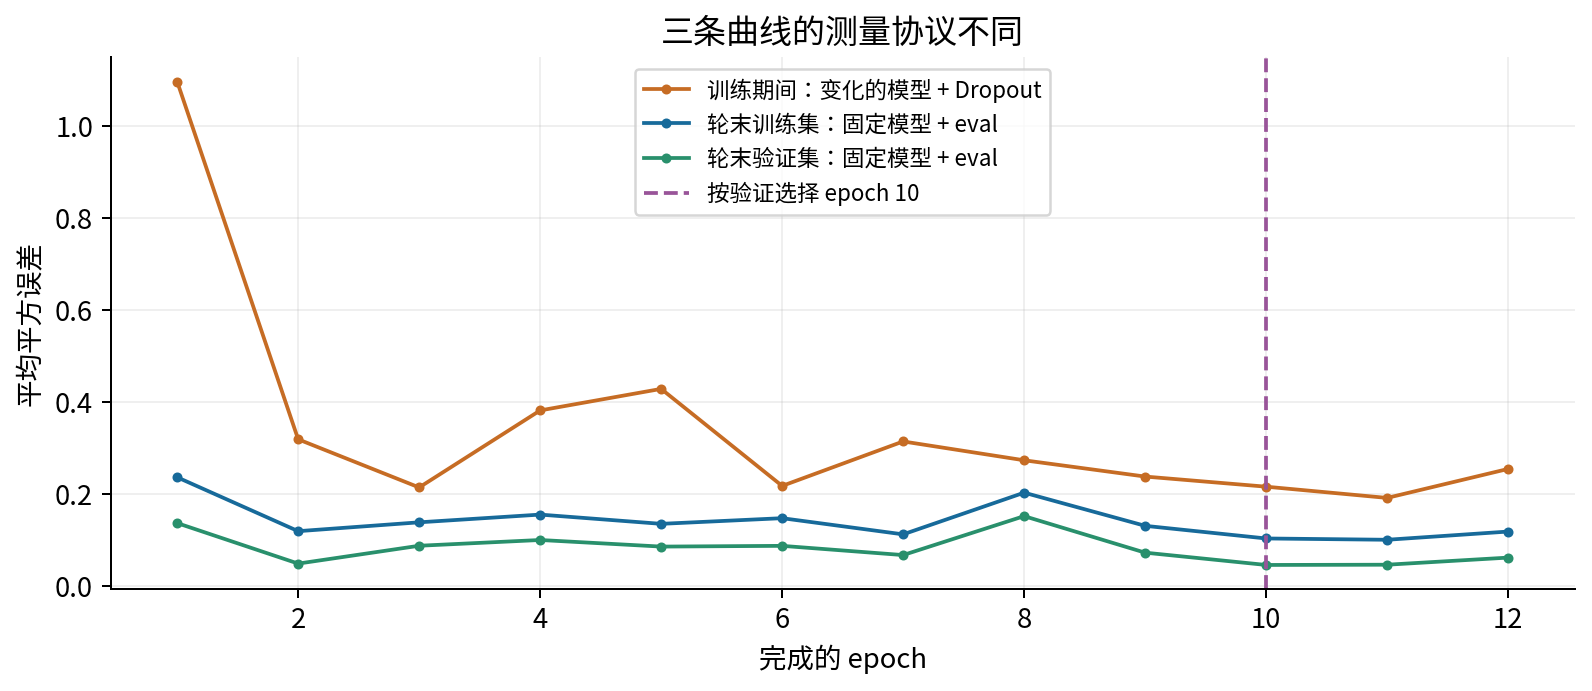

In [9]:
from IPython.display import Image, display
display(Image(filename=str(ROOT/'figures/06_history.png')))

## 读取可信检查点并重建对象
这里只证明同一内核中的对象恢复；真正的新进程命令见lab.pdf，制作时也已实际执行。

In [10]:
state=e.load_checkpoint_bytes((result_dir/'checkpoint-epoch-04.pt').read_bytes())
print('已完成epoch',state['epoch'],'包含字段',list(state))
resumed=e.restore(state,x,y,split,cfg)
e.train_until(resumed,cfg['epochs'])
final=e.state_to_json(e.checkpoint(resumed))
expected=json.loads((result_dir/'final-state.json').read_text())
if final != expected:
    raise RuntimeError('完整最终状态不相同')
print('参数、buffer、动量、RNG、样本顺序、历史与最佳状态相同')

已完成epoch 4 包含字段 ['format', 'epoch', 'model', 'optimizer', 'torch_rng', 'loader_rng', 'config', 'split', 'input_sha256', 'history', 'orders', 'best', 'best_loss', 'best_epoch', 'runtime']
参数、buffer、动量、RNG、样本顺序、历史与最佳状态相同


## 每一种被遗忘的状态都有后果
这些差异用于反驳精确恢复，不构成优化效果优劣排名。

{
  "optimizer": {
    "final_parameter_max_gap": 0.03149809046244717,
    "same_orders": true,
    "validation_mse": 0.062036918991123756
  },
  "torch_rng": {
    "final_parameter_max_gap": 0.2416286449105305,
    "same_orders": true,
    "validation_mse": 0.08630222464091071
  },
  "loader_rng": {
    "final_parameter_max_gap": 0.33410589685966147,
    "same_orders": false,
    "validation_mse": 0.049157368971609335
  }
}


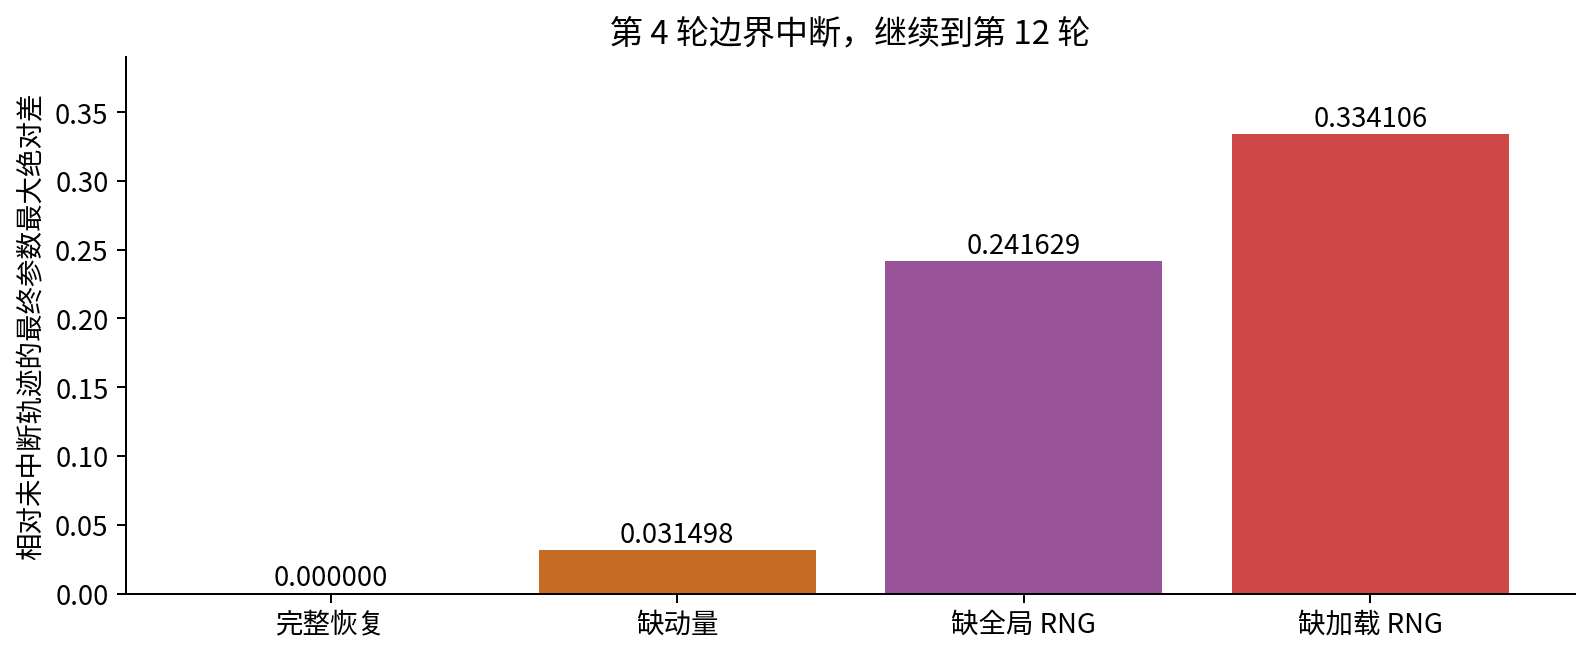

In [11]:
print(json.dumps(summary['ablations'],indent=2))
display(Image(filename=str(ROOT/'figures/08_resume.png')))

## 验证不改变训练状态
核对参数、buffer、已有grad、优化器状态与训练随机源。验证loader自己的无效base seed状态不属于这些不变量。

In [12]:
model=resumed['model']
before=e.clone_state(model)
optimizer_before=copy.deepcopy(resumed['optimizer'].state_dict())
rng_before=torch.get_rng_state().clone()
g_before=resumed['generator'].get_state().clone()
metric=e.evaluate(model,resumed['loaders']['validation'])
print('验证MSE',metric['mse'])
print('模型不变',e.tensor_dict_equal(before,e.clone_state(model)))
print('优化器不变',e.nested_equal(optimizer_before,resumed['optimizer'].state_dict()))
print('两个训练RNG不变',torch.equal(rng_before,torch.get_rng_state()),torch.equal(g_before,resumed['generator'].get_state()))

验证MSE 0.06185900239178052
模型不变 True
优化器不变 True
两个训练RNG不变 True True


## 数据职责的干预证据
改变测试行后重新训练，完整训练状态仍相同；这是代码路径检查，不是用测试指标调参。

In [13]:
x_changed=x.clone(); y_changed=y.clone()
x_changed[split['test']]+=10; y_changed[split['test']]=-50
a=e.make_run(x,y,split,cfg);e.train_until(a,12);a_state=e.checkpoint(a)
b=e.make_run(x_changed,y_changed,split,cfg);e.train_until(b,12);b_state=e.checkpoint(b)
print('测试行干预后训练与选择不变',e.nested_equal(a_state,b_state))

测试行干预后训练与选择不变 True


## 最后评价的含义
12行合成测试MSE约0.13905110。图的对角线不是置信区间，数据规模不支持现实任务结论。

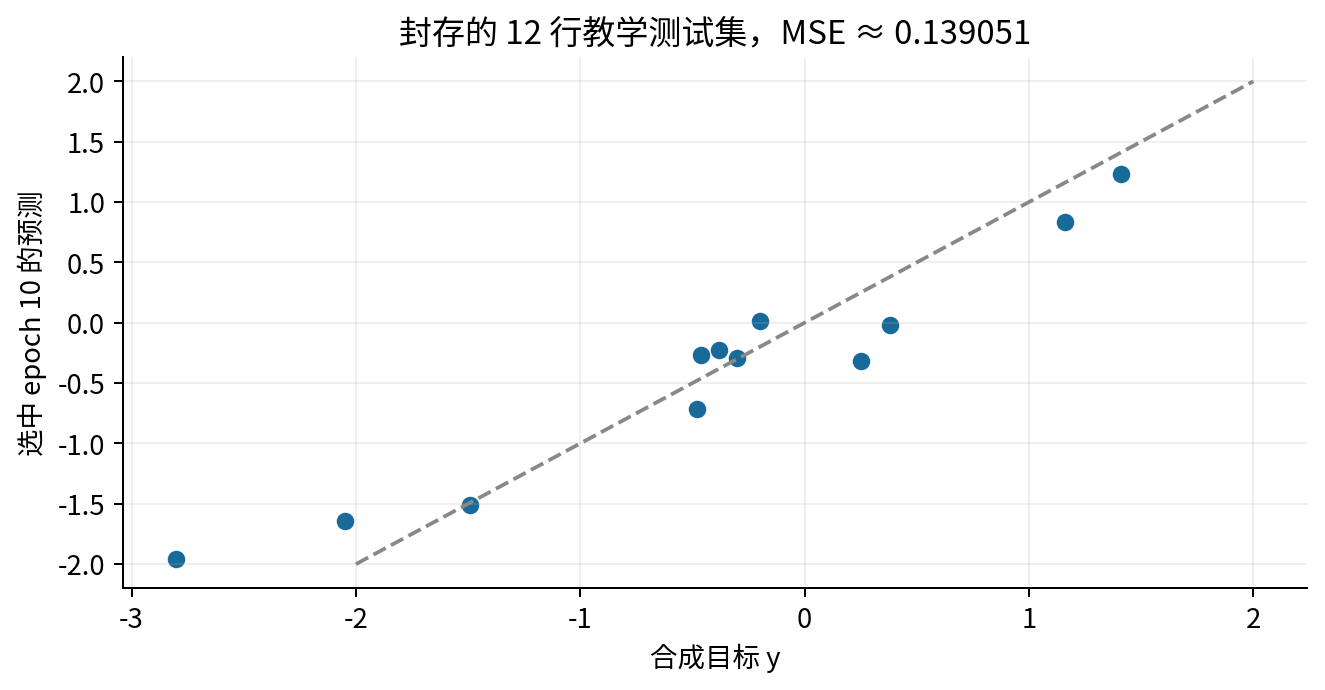

In [14]:
display(Image(filename=str(ROOT/'figures/09_test.png')))

## 检查与下一步
运行完整测试套件；它覆盖独立前向、Fraction动量、九组恢复边界、损坏状态与输入拒绝。使用真实新进程完成lab第6节。

In [15]:
import unittest
import test_experiment
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
check=unittest.TextTestRunner(verbosity=1).run(suite)
if not check.wasSuccessful():
    raise RuntimeError('测试失败')
temporary.cleanup()

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 12 tests in 1.948s

OK


完整边界：CPU float64、单线程、num_workers=0、同一版本、完整epoch边界。浏览器Jupyter与socket传输未实测。没有GPU、随机增强、多worker、调度器、混合精度或跨平台逐位一致承诺。参考sources.md；下一讲用这些证据组织最小调试。